# Notebook 02 — Topic Modeling (Section 3)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy
import gensim
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from pathlib import Path

DATA_PATH = Path("outputs/reviews_clean.csv")
OUTPUTS_DIR = Path("outputs")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Load Data

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} reviews")
texts = df['text'].dropna().tolist()
print(f"Using {len(texts)} texts for topic modeling")

Loaded 24103 reviews
Using 24103 texts for topic modeling


## 2. Preprocessing — Tokenization, Stopwords, Lemmatization

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])
STOP_WORDS = set(stopwords.words('english'))
STOP_WORDS.update(['insurance', 'company', 'would', 'also', 'get', 'one', 'use', 'like', 'review'])

def preprocess(text):
    doc = nlp(str(text).lower())
    tokens = [
        token.lemma_ for token in doc
        if token.is_alpha and not token.is_stop and len(token.text) > 2
        and token.lemma_ not in STOP_WORDS
    ]
    return tokens

from tqdm import tqdm
print("Preprocessing texts...")
processed_texts = [preprocess(t) for t in tqdm(texts[:5000])]  # use first 5000 for speed
print(f"Done. Sample: {processed_texts[0][:10]}")

Preprocessing texts...


100%|██████████| 5000/5000 [00:22<00:00, 219.22it/s]

Done. Sample: ['good', 'price', 'solution', 'listening', 'speed', 'recommend', 'attractive', 'price', 'quality', 'service']


## 3. Build Dictionary and Corpus

In [5]:
# Build vocabulary
dictionary = corpora.Dictionary(processed_texts)
# Filter extremes: ignore very rare and very common words
dictionary.filter_extremes(no_below=5, no_above=0.5)
print(f"Dictionary size: {len(dictionary)} terms")

# Create bag-of-words corpus
corpus = [dictionary.doc2bow(doc) for doc in processed_texts]
print(f"Corpus: {len(corpus)} documents")

Dictionary size: 2083 terms
Corpus: 5000 documents


## 4. Tune Number of Topics by Coherence Score

Tuning topics:  11%|█         | 1/9 [00:04<00:36,  4.60s/it]

k=3: coherence=0.4849


Tuning topics:  22%|██▏       | 2/9 [00:08<00:31,  4.48s/it]

k=4: coherence=0.5029


Tuning topics:  33%|███▎      | 3/9 [00:13<00:26,  4.45s/it]

...

k=9: coherence=0.5067


Tuning topics:  89%|████████▉ | 8/9 [00:36<00:04,  4.51s/it]

k=10: coherence=0.4938


Tuning topics: 100%|██████████| 9/9 [00:40<00:00,  4.53s/it]

k=11: coherence=0.4651


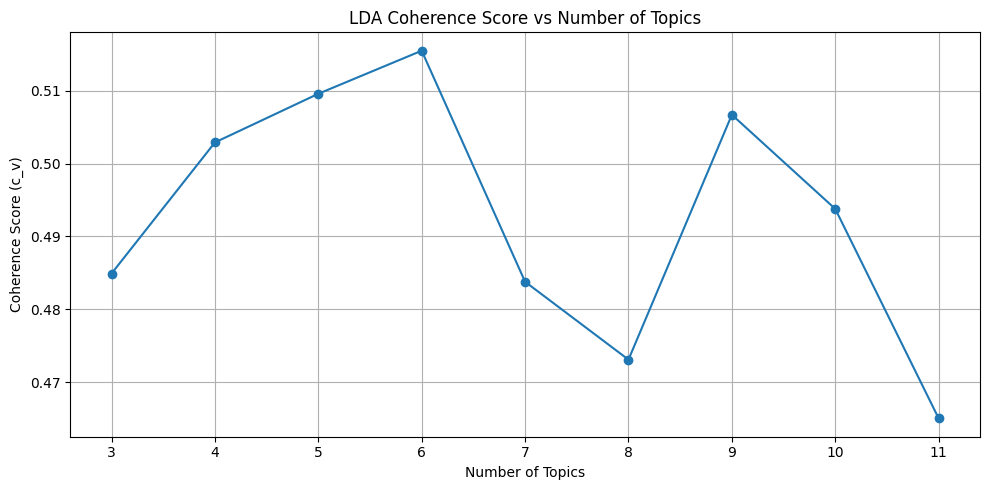


Best k = 6 with coherence = 0.5155


In [6]:
coherence_scores = []
topic_range = range(3, 12)

for k in tqdm(topic_range, desc="Tuning topics"):
    lda = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=42,
        passes=5,
        alpha='auto',
        per_word_topics=True
    )
    coherence_model = CoherenceModel(
        model=lda, texts=processed_texts,
        dictionary=dictionary, coherence='c_v'
    )
    coherence_scores.append(coherence_model.get_coherence())
    print(f"k={k}: coherence={coherence_scores[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(list(topic_range), coherence_scores, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.title('LDA Coherence Score vs Number of Topics')
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'lda_coherence.png', dpi=100)
plt.show()

best_k = list(topic_range)[np.argmax(coherence_scores)]
print(f"\nBest k = {best_k} with coherence = {max(coherence_scores):.4f}")

## 5. Train Final LDA Model

In [7]:
print(f"Training LDA with k={best_k}...")
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=best_k,
    random_state=42,
    passes=10,
    alpha='auto',
    per_word_topics=True
)

lda_model.save(str(MODELS_DIR / 'lda_model'))
dictionary.save(str(MODELS_DIR / 'lda_dictionary'))
print("Model saved.")

Training LDA with k=6...
Model saved.


## 6. Display Top Words per Topic

In [8]:
print("Top words per topic:\n")
for topic_id in range(best_k):
    words = lda_model.show_topic(topic_id, topn=10)
    word_str = ", ".join([w for w, _ in words])
    print(f"Topic {topic_id}: {word_str}")

Top words per topic:

Topic 0: contract, tell, month, time, contact, ask, email, phone, answer, file
Topic 1: car, year, vehicle, claim, accident, expert, insure, matmut, risk, responsible
Topic 2: price, service, satisfied, good, recommend, thank, fast, customer, simple, offer
Topic 3: file, month, expert, send, request, work, pay, take, reimbursement, time
Topic 4: contract, mutual, receive, send, customer, terminate, termination, card, request, email
Topic 5: year, vehicle, euro, increase, pay, customer, car, contract, price, accident


## 7. Visualize with pyLDAvis

In [9]:
vis = gensimvis.prepare(lda_model, corpus, dictionary)
pyLDAvis.save_html(vis, str(OUTPUTS_DIR / 'lda_visualization.html'))
print("Saved LDA visualization to outputs/lda_visualization.html")
# Display inline if in Jupyter
pyLDAvis.enable_notebook()
vis

Saved LDA visualization to outputs/lda_visualization.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
2     -0.297171  0.077863       1        1  22.506347
5      0.043353  0.079844       2        1  20.945899
0      0.007027 -0.091822       3        1  18.392210
3      0.091164 -0.134426       4        1  15.280507
4     -0.006445 -0.127399       5        1  14.944557
1      0.162071  0.195939       6        1   7.930480, topic_info=          Term         Freq        Total Category  logprob  loglift
21   satisfied  1142.000000  1142.000000  Default  30.0000  30.0000
3        price  1602.000000  1602.000000  Default  29.0000  29.0000
75        year  1457.000000  1457.000000  Default  28.0000  28.0000
6      service  1703.000000  1703.000000  Default  27.0000  27.0000
26         car   590.000000   590.000000  Default  26.0000  26.0000
..         ...          ...          ...      ...      ...      ...
198     direct    54.749464   347.766048   Topic6  -5.0179   0.6857
104      month    62.764090   872.361968   Topic6  -4.8813  -0.0974
389       want    52.442689   367.336386   Topic6  -5.0610   0.5879
63         pay    56.856158   788.838192   Topic6  -4.9802  -0.0956
51        find    52.744837   461.030141   Topic6  -5.0552   0.3665

[470 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1353      4  0.930420  abnormal
783       2  0.967484    absent
76        3  0.054457   abusive
76        5  0.925768   abusive
485       2  0.558107  accident
...     ...       ...       ...
75        2  0.721086      year
75        3  0.008919      year
75        4  0.042538      year
75        5  0.098112      year
75        6  0.127614      year

[946 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[3, 6, 1, 4, 5, 2])

## 8. Assign Topic to Each Review

In [10]:
def get_dominant_topic(bow):
    topic_dist = lda_model.get_document_topics(bow)
    if not topic_dist:
        return -1
    return max(topic_dist, key=lambda x: x[1])[0]

df_topics = pd.DataFrame({'text': texts[:5000]})
bows = [dictionary.doc2bow(preprocess(t)) for t in texts[:5000]]
df_topics['dominant_topic'] = [get_dominant_topic(bow) for bow in bows]

# Get topic keywords
topic_keywords = {}
for i in range(best_k):
    words = lda_model.show_topic(i, topn=5)
    topic_keywords[i] = ", ".join([w for w, _ in words])

df_topics['topic_keywords'] = df_topics['dominant_topic'].map(topic_keywords)
print(df_topics['dominant_topic'].value_counts())
df_topics.head(5)

dominant_topic
2    2054
5     926
0     654
4     574
3     545
1     247
Name: count, dtype: int64


,text,dominant_topic,topic_keywords
0,"Best insurance, price, solutions, listening, s...",2,"price, service, satisfied, good, recommend"
1,"I am generally satisfied, except that you have...",2,"price, service, satisfied, good, recommend"
2,Very affordable price Several options are avai...,2,"price, service, satisfied, good, recommend"
3,"I satisfy the service, a very fast response fr...",2,"price, service, satisfied, good, recommend"
4,"Customer for more than 25 years, very disappoi...",5,"year, vehicle, euro, increase, pay"


## Summary
- Preprocessed reviews with spaCy lemmatization + stopword removal
- Tuned LDA from k=3 to k=11 by coherence score
- Trained final model and saved to `models/`
- Visualized with pyLDAvis (saved to `outputs/lda_visualization.html`)